In [128]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline
import numpy as np

In [272]:
sequences = np.load("CMdata.npz")["seqs"]
structures = np.load("CMdata.npz")["strs"]

min_len = 75
max_len = 95

filtered_sequences = [s for s in sequences if min_len <= len(s) <= max_len]
filtered_structures = [v for s, v in zip(sequences,structures) if min_len <= len(s) <= max_len]
sequences = [s + "." for s in filtered_sequences] # Add a stop character to the end of each sequence

## two state SS?

for i in range(len(filtered_structures)):
    filtered_structures[i] = ''.join('H' if c == 'H' else 'C' for c in filtered_structures[i])

structures = [s + "." for s in filtered_structures] # Add a stop character to the end of each structure

# Check the lengths of the sequences and structures

for i in range(len(sequences)):
    assert len(sequences[i]) == len(structures[i]), f"Length mismatch at index {i}: {len(sequences[i])} vs {len(structures[i])}"

In [ ]:
# build the vocabulary of characters and mappings to/from integers
chars = [
    s + v
    for seq, strc in zip(sequences, structures)
    for s, v in zip(seq , strc)
    ]

chars = sorted(set(chars))

stoi = {s:i for i,s in enumerate(chars)}
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{0: '..', 1: 'AC', 2: 'AH', 3: 'CC', 4: 'CH', 5: 'DC', 6: 'DH', 7: 'EC', 8: 'EH', 9: 'FC', 10: 'FH', 11: 'GC', 12: 'GH', 13: 'HC', 14: 'HH', 15: 'IC', 16: 'IH', 17: 'KC', 18: 'KH', 19: 'LC', 20: 'LH', 21: 'MC', 22: 'MH', 23: 'NC', 24: 'NH', 25: 'PC', 26: 'PH', 27: 'QC', 28: 'QH', 29: 'RC', 30: 'RH', 31: 'SC', 32: 'SH', 33: 'TC', 34: 'TH', 35: 'VC', 36: 'VH', 37: 'WC', 38: 'WH', 39: 'YC', 40: 'YH'}
41


In [ ]:
# Set the device for PyTorch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [ ]:
# Build the datasets

block_size = 70 # size of the autoregressive window

def build_dataset(sequences, structures):
  X, Y = [], []

  for seq, strc in zip(sequences, structures):
    context = [0] * block_size
    tokens = [s + v for s, v in zip(seq, strc)]  # add end token
    
    for tok in tokens:
        ix = stoi[tok]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]  # crop and append
        #print(context)

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
combined = list(zip(sequences, structures))
random.shuffle(combined)
sequences, structures = zip(*combined)
sequences = list(sequences)
structures = list(structures)

# Split the dataset into training and development sets
n2 = int(0.9*len(sequences))
Xtr,  Ytr  = build_dataset(sequences[:n2], structures[:n2])    # 90%
Xdev, Ydev = build_dataset(sequences[n2:], structures[n2:])   # 10%


Xtr = Xtr.to(device)
Ytr = Ytr.to(device)
Xdev = Xdev.to(device)
Ydev = Ydev.to(device)


torch.Size([634200, 70]) torch.Size([634200])
torch.Size([70531, 70]) torch.Size([70531])


In [ ]:
n_embd = 13 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator(device=device).manual_seed(1) # for reproducibility
C = torch.randn((vocab_size, n_embd), generator=g, device=device)

layers = [
  nn.Linear(n_embd * block_size, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  #nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  #nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  #nn.Linear(           n_hidden, n_hidden, bias=False), nn.BatchNorm1d(n_hidden), nn.Tanh(),
  nn.Linear(           n_hidden, vocab_size, bias=False), nn.BatchNorm1d(vocab_size),
]

for layer in layers:
  layer.to(device)

with torch.no_grad():
  # last layer: make less confident
  layers[-1].weight *= 0.1
  #layers[-1].weight *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, nn.Linear):
      layer.weight *= 1

parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True


# Adam optimizer and learning rate scheduler, not in use for now

import torch.optim as optim

optimizer = optim.Adam(parameters, lr=1e-4)  # Initial LR
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=150000, gamma=0.1)

231615


In [ ]:
# loss on Aminoacid+Structure tokens

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
    }[split]

    emb = C[x]  # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1)  # (N, block_size * n_embd)

    for layer in layers:
        x = layer(x)  # (N, vocab_size), assuming final layer maps to vocab_size

    # Manual cross-entropy implementation
    # x: (N, vocab_size), y: (N,)
    log_probs = torch.log_softmax(x, dim=1)  # (N, vocab_size)
    nll = -log_probs[torch.arange(y.size(0)), y]  # Negative log-likelihood for correct class

    
    loss = nll.mean()  # Scalar

    print(split, loss.item())


print("loss on Aminoacid+Structure tokens")
split_loss('train')
split_loss('val')

#we expect around 3, if the initialization is good the probability given to the good token is 1/20 that is e-3

loss on Aminoacid+Structure tokens
train 0.8418739438056946
val 1.20010507106781


In [274]:
# Loss on Aminoacid tokens only

first_letter_map = {i: token[0] for i, token in itos.items()}

# 2. Create group indices for each unique first letter
unique_letters = sorted(set(first_letter_map.values()))
letter_to_group = {ch: i for i, ch in enumerate(unique_letters)}

# 3. For each token index, find the group index based on its first letter
token_to_group = torch.tensor([letter_to_group[first_letter_map[i]] for i in range(len(itos))])  # (54,)
n_groups = len(unique_letters)  # typically 20 (for 20 amino acids)

def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
    }[split]

    emb = C[x]  # (N, block_size, n_embd)
    x = emb.view(emb.shape[0], -1)  # (N, block_size * n_embd)

    for layer in layers:
        x = layer(x)  # (N, 54) — raw logits over 54 tokens

    # Step 1: Compute softmax over original logits
    probs = torch.softmax(x, dim=1)  # (N, 54)

    # Step 2: Sum probabilities by first-letter groups
    grouped_probs = torch.zeros(x.size(0), n_groups, device=x.device)  # (N, n_groups)
    grouped_probs.index_add_(1, token_to_group.to(x.device), probs)  # add probs by group

    # Step 3: Map target token to its group (based on first letter)
    target_group = token_to_group[y]  # (N,)

    # Step 4: Compute log and negative log-likelihood
    log_grouped_probs = torch.log(grouped_probs + 1e-9)  # avoid log(0)
    nll = -log_grouped_probs[torch.arange(y.size(0)), target_group]
    loss = nll.mean()

    print(split, loss.item())

print("loss on Aminoacid tokens only")
split_loss('train')
split_loss('val')

loss on Aminoacid tokens only
train 0.8142625093460083
val 1.1438946723937988


In [146]:
g = torch.Generator(device=device).manual_seed(1) # for reproducibility
max_steps = 90001
batch_size = 256
lossi = []
ud = []

lri = (torch.logspace(-4,0,max_steps))


for i in range(max_steps):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g, device = device)
  Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function

  # backward pass
  #optimizer.zero_grad()

  for p in parameters:
    p.grad = None
  loss.backward()


  # update
  #optimizer.step()
  #scheduler.step()

  lr = 0.01 if i < 60000 else 0.001 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print('epoch    ',f'{i}')
    split_loss('val')
    split_loss('train')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  #if i >= 10000:
   # break # AFTER_DEBUG: would take out obviously to run full optimization
  

# --- Saving ---

param_dict = {}
param_dict['C'] = C.detach().cpu().numpy()
for i, layer in enumerate(layers):
    for name, param in layer.named_parameters():
        param_dict[f'layer_{i}_{name}'] = param.detach().cpu().numpy()
np.savez(f'nn_parameters_{batch_size}_ss2s.npz', **param_dict)


epoch     0
val 3.0308830738067627
train 3.0308315753936768
epoch     10000
val 1.3279067277908325
train 1.222286581993103
epoch     20000
val 1.2228367328643799
train 1.072782278060913
epoch     30000
val 1.1916687488555908
train 1.001137614250183
epoch     40000
val 1.175277590751648
train 0.9506314992904663
epoch     50000
val 1.1703479290008545
train 0.9169352054595947
epoch     60000
val 1.1616249084472656
train 0.8821972608566284
epoch     70000
val 1.139288306236267
train 0.8273494243621826
epoch     80000
val 1.1423267126083374
train 0.8192376494407654
epoch     90000
val 1.144726037979126
train 0.8137138485908508


In [275]:
# Loading a trained model
with torch.no_grad():

    loaded = np.load('nn_parameters_256_ss2s.npz')
    C.copy_(torch.tensor(loaded['C'], device=C.device))
    for i, layer in enumerate(layers):
        for name, param in layer.named_parameters():
            param.copy_(torch.tensor(loaded[f'layer_{i}_{name}'], device=param.device))

In [276]:
split_loss('train')
split_loss('val')

train 0.8142625093460083
val 1.1438946723937988


layer 2 (      Tanh): mean +0.00, std 0.65, saturated: 6.73%
layer 5 (      Tanh): mean +0.00, std 0.66, saturated: 6.17%


Text(0.5, 1.0, 'activation distribution')

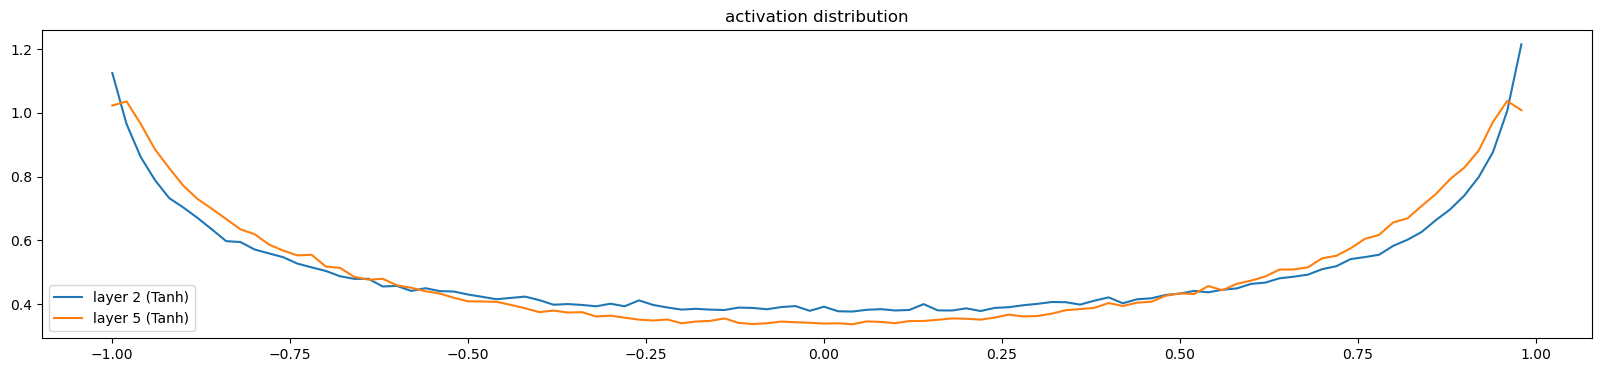

In [278]:
# How many activation functions are saturated? (|t| > 0.97)

emb = C[Xdev] # embed the characters into vectors
x = emb.view(emb.shape[0], -1)


activations = []

for i, layer in enumerate(layers):
    x = layer(x)
    if isinstance(layer, nn.Tanh):  # or nn.ReLU, nn.LeakyReLU, etc.
        activations.append((i, layer.__class__.__name__, x.detach().cpu().view(-1)))

# Plotting
plt.figure(figsize=(20, 4))
legends = []

for i, name, t in activations:
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' %
          (i, name, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, bins=100, density=True)
    plt.plot(hx[:-1], hy)
    legends.append(f'layer {i} ({name})')

plt.legend(legends)
plt.title('activation distribution')


layer 2 (      Tanh): grad mean +0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh): grad mean -0.00, std 0.00, saturated: 0.00%


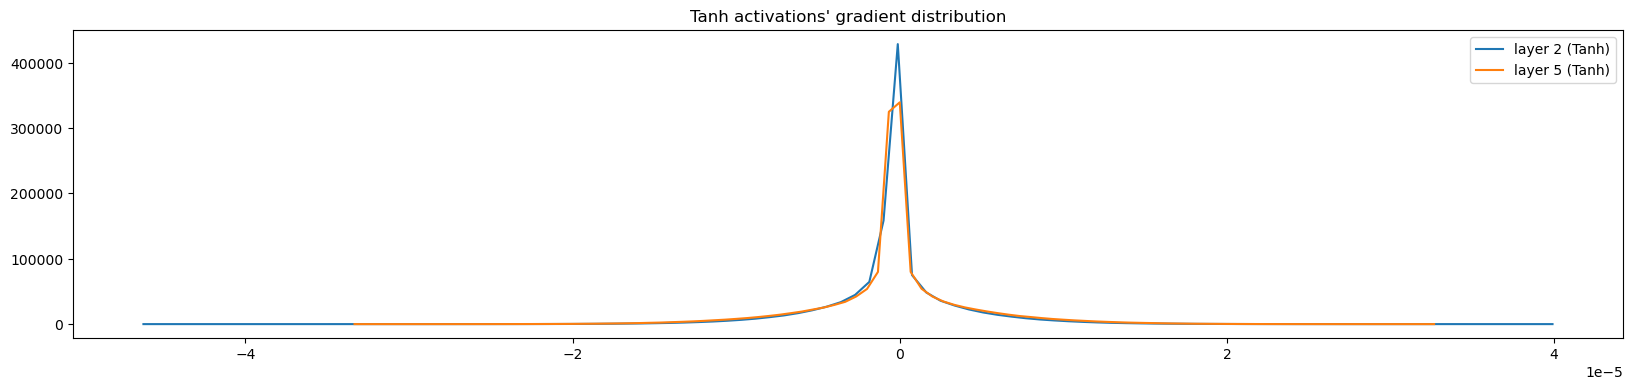

In [279]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# Example dummy input
emb = C[Xdev]  # Embedding step
x = emb.view(emb.shape[0], -1)  # Flatten

activations = []

# Forward pass and retain gradients for Tanh outputs
for i, layer in enumerate(layers):
    x = layer(x)
    if isinstance(layer, nn.Tanh):
        x.retain_grad()  # <-- retain gradient for this activation
        activations.append((i, layer.__class__.__name__, x))

# Compute loss and backward
logits = x  # Assume last x is model output
loss = F.cross_entropy(logits, Ydev)  # Assume Ydev is your target
loss.backward()

# Plotting gradients of Tanh activations
plt.figure(figsize=(20, 4))
legends = []

for i, name, act in activations:
    g = act.grad  # now it should exist
    if g is None:
        continue
    g = g.detach().cpu().view(-1)
    print('layer %d (%10s): grad mean %+.2f, std %.2f, saturated: %.2f%%' %
          (i, name, g.mean(), g.std(), (g.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(g, bins=100, density=True)
    plt.plot(hx[:-1], hy)
    legends.append(f'layer {i} ({name})')

plt.legend(legends)
plt.title("Tanh activations' gradient distribution")
plt.show()

weight   (41, 13) | mean -0.000066 | std 5.534107e-03 | grad:data ratio 5.420218e-03
weight (200, 910) | mean -0.000144 | std 9.965958e-03 | grad:data ratio 3.448264e-01
weight (200, 200) | mean +0.000024 | std 1.610774e-02 | grad:data ratio 3.070905e-01
weight  (41, 200) | mean +0.000003 | std 2.138864e-02 | grad:data ratio 3.208868e-01


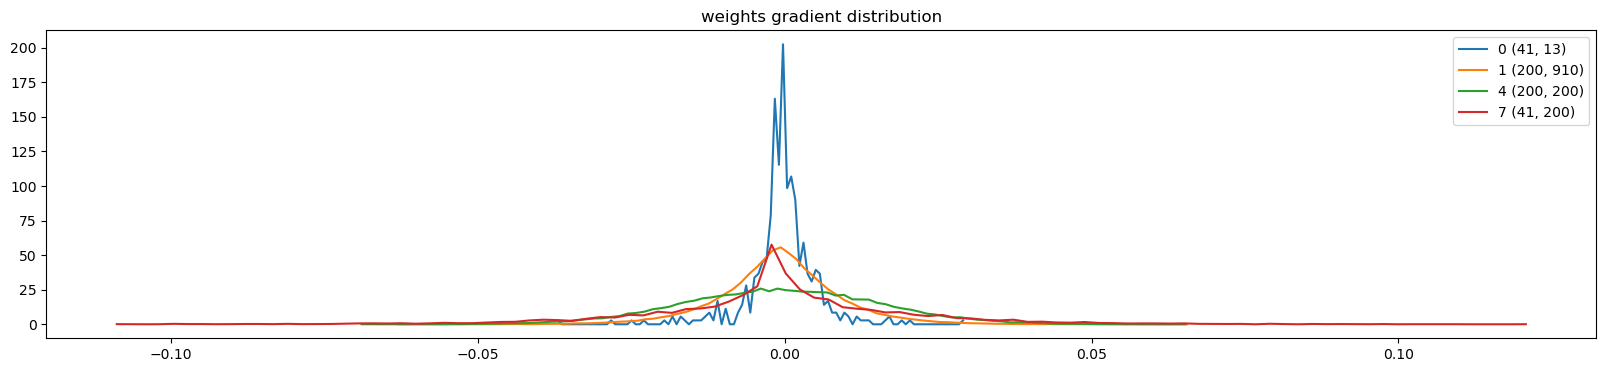

In [280]:
plt.figure(figsize=(20, 4))
legends = []

for i, p in enumerate(parameters):
    t = p.grad
    if t is None:
        continue  # skip if grad is None (e.g., frozen layers)

    if p.ndim == 2:
        t = t.detach().cpu().view(-1)  # flatten & move to CPU
        param_std = p.std().detach().cpu()
        grad_std = t.std()
        print('weight %10s | mean %+f | std %e | grad:data ratio %e' %
              (tuple(p.shape), t.mean(), grad_std, grad_std / param_std))

        hy, hx = torch.histogram(t, bins=100, density=True)
        plt.plot(hx[:-1].cpu(), hy.cpu())  # ensure plotting from CPU
        legends.append(f'{i} {tuple(p.shape)}')

plt.legend(legends)
plt.title('weights gradient distribution')
plt.show()


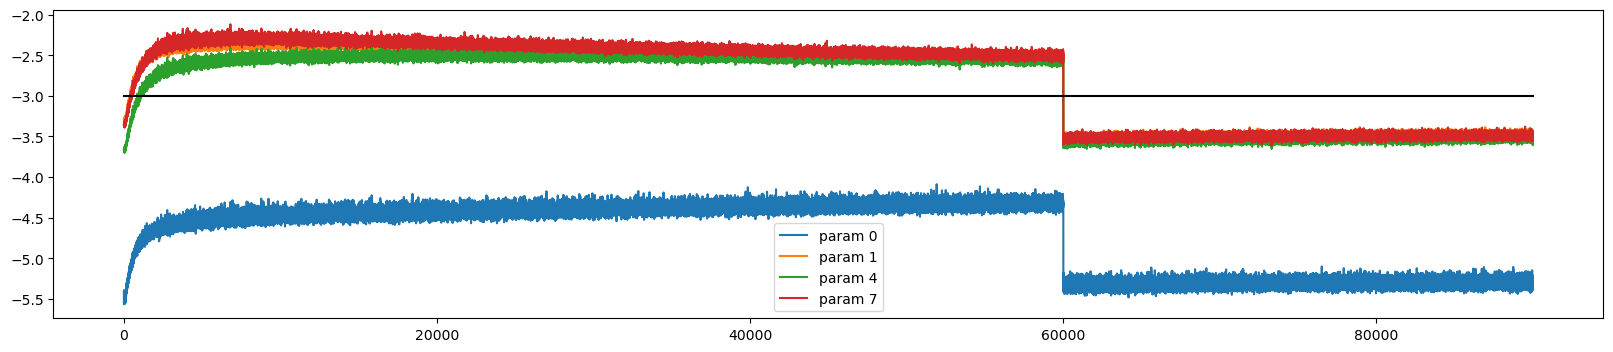

In [ ]:
# Parameter change std / parameter value std (ratio)

plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
 if p.ndim == 2:
   plt.plot([ud[j][i] for j in range(len(ud))])
   legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [ ]:
# Generate Sequences + Structures

g = torch.Generator(device=device).manual_seed(0)
n = 1000

for layer in layers:
    layer.eval()

with open('generated_sequences_ss2s.txt', 'w') as f:
    for _ in range(n):
        out = []
        context = [0] * block_size  # initialize with all ...
        while True:
            emb = C[torch.tensor([context])]  # (1, block_size, n_embd)
            x = emb.view(emb.shape[0], -1)  # flatten
            for layer in layers:
                x = layer(x)
            logits = x
            probs = F.softmax(logits, dim=1)
            ix = torch.multinomial(probs, num_samples=1, generator=g).item()
            context = context[1:] + [ix]
            out.append(ix)
            if ix == 0:  # special token
                break

        sequence = ''.join(itos[i][0] for i in out[0:-1])
        structure = ''.join(itos[i][1] for i in out[0:-1])
        header = f'>seq_{_}'
        #print(header)
        #print(sequence)
        f.write(header + '\n')
        f.write(sequence + '\n')
        f.write(structure + '\n')

In [ ]:
### Outils for predicting structures on DEV set


def create_vector(n):
    if not (0 <= n < 41):
        raise ValueError("Input must be between 0 and 40 inclusive.")

    vec = [0] * 41
    

    if n % 2 == 1:  # Odd
        vec[n] = 1
        if n + 1 < 41:
            vec[n + 1] = 1
    else:  # Even
        vec[n] = 1
        if n - 1 >= 0:
            vec[n - 1] = 1

    return vec



In [284]:
# predicting the structures on the DEV set

seq_dev = sequences[n2:]
struct_dev = structures[n2:]

with open('predicted_DEV_structures.txt', 'w') as f:
    for _ in range(len(seq_dev)):
        out = []
        context = [0] * block_size  # initialize with all ...
        sqi = 0
        while sqi < len(seq_dev[_]):
            emb = C[torch.tensor([context])]  # (1, block_size, n_embd)
            x = emb.view(emb.shape[0], -1)  # flatten
            for layer in layers:
                x = layer(x)
            logits = x

            temp = [stoi[seq_dev[_][sqi] + struct_dev[_][sqi]] for i in range(len(seq_dev[_]))]
            mask = create_vector(temp[sqi])
            probs = F.softmax(logits, dim=1) * torch.tensor(mask, device=device)

            ix = torch.argmax(probs).item() # autoregressive maximum structure token

            context = context[1:] + [ix]
            out.append(ix)
            sqi += 1
            if ix == 0:  # special token
                #print(out)
                break

        sequence = ''.join(itos[i][0] for i in out[0:-1])
        structure = ''.join(itos[i][1] for i in out[0:-1])
        header = f'>DEV_seq_{_}'
        #print(header)
        #print(sequence)
        f.write(header + '\n')
        f.write(sequence + '\n')
        f.write(structure + '  Predicted_one\n')
        f.write(struct_dev[_][0:-1] + '  True_one\n')

<BarContainer object of 13 artists>

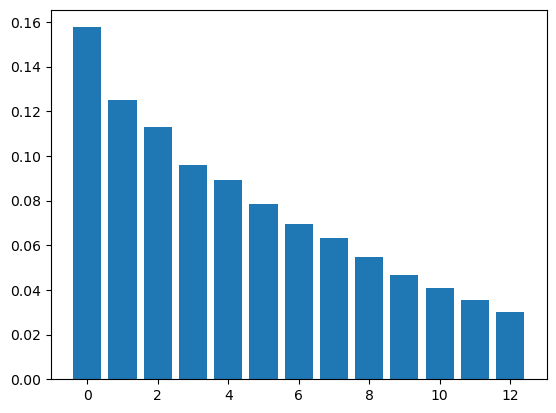

In [285]:
# Analyzing the embedding (first two PCA)

import sklearn
from sklearn.decomposition import PCA
import numpy as np

# Example data: rows = samples, columns = features
X = np.random.rand(100, 50)  # 100 samples, 50 features

# Apply PCA to reduce to 2 dimensions
pca = PCA(n_components=13)
C_pca = pca.fit_transform(C.detach().numpy())
plt.bar(range(13), pca.explained_variance_ratio_)


In [287]:
# Define color schemes based on aminoacid properties

affinity = [   "black",           # ..       ##idro-affinity
    "red", "red",      # A
    "red", "red",      # C
    "blue", "blue",    # D
    "blue", "blue",    # E
    "red", "red",      # F
    "yellow", "yellow",# G
    "yellow", "yellow",# H
    "red", "red",      # I
    "blue", "blue",    # K
    "red", "red",      # L
    "red", "red",      # M
    "blue", "blue",    # N
    "yellow", "yellow",# P
    "blue", "blue",    # Q
    "blue", "blue",    # R
    "yellow", "yellow",# S
    "yellow", "yellow",# T
    "red", "red",      # V
    "red", "red",      # W
    "yellow", "yellow" # Y
]


size = ["black",               ## size
    "blue", "blue",     # A
    "blue", "blue",     # C
    "blue", "blue",     # D
    "yellow", "yellow", # E
    "red", "red",       # F
    "blue", "blue",     # G
    "yellow", "yellow", # H
    "red", "red",       # I
    "red", "red",       # K
    "red", "red",       # L
    "red", "red",       # M
    "blue", "blue",     # N
    "blue", "blue",     # P
    "yellow", "yellow", # Q
    "red", "red",       # R
    "blue", "blue",     # S
    "blue", "blue",     # T
    "yellow", "yellow", # V
    "red", "red",       # W
    "red", "red"        # Y
]

charge = ["black",                # charge
    "yellow", "yellow",  # A
    "yellow", "yellow",  # C
    "blue", "blue",      # D
    "blue", "blue",      # E
    "yellow", "yellow",  # F
    "yellow", "yellow",  # G
    "red", "red",        # H
    "yellow", "yellow",  # I
    "red", "red",        # K
    "yellow", "yellow",  # L
    "yellow", "yellow",  # M
    "yellow", "yellow",  # N
    "yellow", "yellow",  # P
    "yellow", "yellow",  # Q
    "red", "red",        # R
    "yellow", "yellow",  # S
    "yellow", "yellow",  # T
    "yellow", "yellow",  # V
    "yellow", "yellow",  # W
    "yellow", "yellow"   # Y
]




polarity = ["black",            # polarity
    "yellow", "yellow",  # A
    "yellow", "yellow",  # C
    "blue", "blue",      # D
    "blue", "blue",      # E
    "yellow", "yellow",  # F
    "yellow", "yellow",  # G
    "blue", "blue",      # H
    "yellow", "yellow",  # I
    "blue", "blue",      # K
    "yellow", "yellow",  # L
    "yellow", "yellow",  # M
    "blue", "blue",      # N
    "yellow", "yellow",  # P
    "blue", "blue",      # Q
    "blue", "blue",      # R
    "blue", "blue",      # S
    "blue", "blue",      # T
    "yellow", "yellow",  # V
    "yellow", "yellow",  # W
    "blue", "blue"       # Y
]

ss_state = ["black",                # ss_state
    "red", "blue", "red", "blue", "red", "blue", "red", "blue", "red", "blue",
    "red", "blue", "red", "blue", "red", "blue", "red", "blue", "red", "blue",
    "red", "blue", "red", "blue", "red", "blue", "red", "blue", "red", "blue",
    "red", "blue", "red", "blue", "red", "blue", "red", "blue", "red", "blue"
]

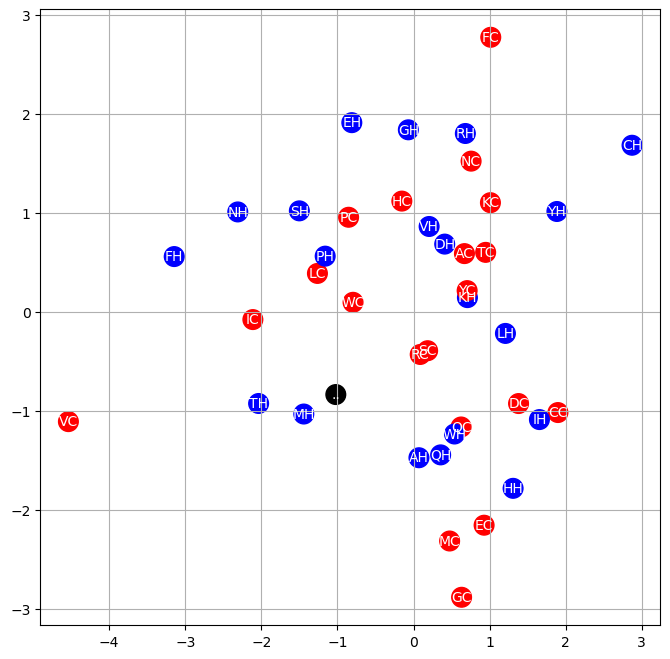

In [288]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C_pca[:,0].data, C_pca[:,1].data, s=200, c = ss_state)
for i in range(C_pca.shape[0]):
    plt.text(C_pca[i,0].item(), C_pca[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')